In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:
import shutil
import os

if os.path.exists("/content/dataset"):
    shutil.rmtree("/content/dataset")

print("Old dataset removed.")

Old dataset removed.


In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install torch torchvision torchsummary scikit-learn seaborn grad-cam -q


# ============================================================
# IMPORTS
# ============================================================

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from PIL import Image

import cv2


# ============================================================
# RANDOM SEED = 42
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)


# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# DATASET EXTRACTION
# ============================================================

ZIP_PATH = "/content/drive/MyDrive/medicinalLeafDataset.zip"

DATASET_PATH = "/content/dataset"

if not os.path.exists(DATASET_PATH):

    with zipfile.ZipFile(
        ZIP_PATH,
        'r'
    ) as zip_ref:

        zip_ref.extractall(
            DATASET_PATH
        )

print("Dataset Extracted Successfully")


# ============================================================
# DATASET PATHS
# ============================================================

TRAIN_DIR = os.path.join(
    DATASET_PATH,
    "train"
)

VALID_DIR = os.path.join(
    DATASET_PATH,
    "valid"
)

TEST_DIR = os.path.join(
    DATASET_PATH,
    "test"
)

print(TRAIN_DIR)
print(VALID_DIR)
print(TEST_DIR)


# ============================================================
# HYPERPARAMETERS
# ============================================================

IMG_SIZE = 224

BATCH_SIZE = 64


# ============================================================
# DATA AUGMENTATION
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomRotation(
        20
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomAffine(
        degrees=0,
        shear=20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])



test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])


# ============================================================
# DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    VALID_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


# ============================================================
# CLASS INFORMATION
# ============================================================

CLASS_NAMES = train_dataset.classes

NUM_CLASSES = len(
    CLASS_NAMES
)

print("\nClasses Found:")
print(CLASS_NAMES)

print(
    "\nNumber of Classes:",
    NUM_CLASSES
)

print(
    "Training Images:",
    len(train_dataset)
)

print(
    "Validation Images:",
    len(valid_dataset)
)

print(
    "Testing Images:",
    len(test_dataset)
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 73.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Device : cuda
Mounted at /content/drive
Dataset Extracted Successfully
/content/dataset/train
/content/dataset/valid
/content/dataset/test

Classes Found:
['Aloe_barbadensis_miller', 'Azadirachta_indica', 'Calotropis_gigantea', 'Centella_asiatica', 'Hibiscus_rosa_sinensis', 'Justicia_adhatoda', 'Kalanchoe_pinnata', 'Mentha_arvensis', 'Mikania_micrantha', 'Moringa_oleifera', 'Ocimum_tenuiflorum', 'Phyllanthus_emblica', 'Terminalia_arjuna', 'Weed']

Number of Classes: 14
Training Images: 32026
Validation Images: 711
Testing Images: 423


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    if len(dirs) > 0:
        print("Folders:", dirs[:10])
    print("-"*50)

/content/dataset
Folders: ['train', 'test']
--------------------------------------------------
/content/dataset/train
Folders: ['Azadirachta_indica', 'Aloe_barbadensis_miller']
--------------------------------------------------
/content/dataset/train/Azadirachta_indica
--------------------------------------------------
/content/dataset/train/Aloe_barbadensis_miller
--------------------------------------------------
/content/dataset/test
Folders: ['Terminalia_arjuna', 'Moringa_oleifera', 'Justicia_adhatoda', 'Calotropis_gigantea', 'Hibiscus_rosa_sinensis', 'Ocimum_tenuiflorum', 'Azadirachta_indica', 'Mikania_micrantha', 'Aloe_barbadensis_miller', 'Phyllanthus_emblica']
--------------------------------------------------
/content/dataset/test/Terminalia_arjuna
--------------------------------------------------
/content/dataset/test/Moringa_oleifera
--------------------------------------------------
/content/dataset/test/Justicia_adhatoda
--------------------------------------------------


In [ ]:
# ============================================================
# TOTAL VARIATION LOSS
# ============================================================

def total_variation_loss(x):

    loss_h = torch.mean(
        torch.abs(
            x[:, :, 1:, :] -
            x[:, :, :-1, :]
        )
    )

    loss_w = torch.mean(
        torch.abs(
            x[:, :, :, 1:] -
            x[:, :, :, :-1]
        )
    )

    return loss_h + loss_w


# ============================================================
# EDGE BRANCH
# ============================================================

class EdgeBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(16),

            nn.LeakyReLU(0.2)

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                16,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(16),

            nn.LeakyReLU(0.2)

        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        tv = total_variation_loss(x)

        return x, tv


# ============================================================
# COLOR BRANCH
# ============================================================

class ColorBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=1,
                stride=2,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.LeakyReLU(0.2)

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                32,
                3,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(3),

            nn.LeakyReLU(0.2)

        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        tv = total_variation_loss(x)

        return x, tv


# ============================================================
# VEIN BRANCH
# ============================================================

class VeinBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.LeakyReLU(0.2)

        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                32,
                32,
                kernel_size=5,
                stride=2,
                padding=2,
                bias=False
            ),

            nn.BatchNorm2d(32),

            nn.LeakyReLU(0.2)

        )

        self.block3 = nn.Sequential(

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(16),

            nn.LeakyReLU(0.2)

        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        tv = total_variation_loss(x)

        return x, tv


# ============================================================
# MIXER BLOCK
# ============================================================

class MixerBlock(nn.Module):

    def __init__(
        self,
        num_tokens,
        embed_dim,
        token_dim=128,
        channel_dim=256
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(
            embed_dim
        )

        self.token_mixing = nn.Sequential(

            nn.Linear(
                num_tokens,
                token_dim
            ),

            nn.GELU(),

            nn.Linear(
                token_dim,
                num_tokens
            )
        )

        self.norm2 = nn.LayerNorm(
            embed_dim
        )

        self.channel_mixing = nn.Sequential(

            nn.Linear(
                embed_dim,
                channel_dim
            ),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(
                channel_dim,
                embed_dim
            )
        )

    def forward(self, x):

        y = self.norm1(x)

        y = y.transpose(1, 2)

        y = self.token_mixing(y)

        y = y.transpose(1, 2)

        x = x + y

        y = self.norm2(x)

        y = self.channel_mixing(y)

        x = x + y

        return x


# ============================================================
# VEC-TV-MIXER
# ============================================================

class VECTVMixer(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.edge = EdgeBranch()

        self.color = ColorBranch()

        self.vein = VeinBranch()

        self.fusion = nn.Sequential(

            nn.Conv2d(
                35,
                48,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(48),

            nn.LeakyReLU(0.2)

        )

        self.constituent = nn.Sequential(

            nn.Conv2d(
                48,
                64,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(64),

            nn.LeakyReLU(0.2)

        )

        self.down1 = nn.Sequential(

            nn.Conv2d(
                64,
                96,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.GELU()

        )

        self.down2 = nn.Sequential(

            nn.Conv2d(
                96,
                128,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128)

        )

        self.num_tokens = 14 * 14

        self.mixer = nn.Sequential(

            MixerBlock(
                self.num_tokens,
                128
            ),

            MixerBlock(
                self.num_tokens,
                128
            ),

            MixerBlock(
                self.num_tokens,
                128
            ),

            MixerBlock(
                self.num_tokens,
                128
            )

        )

        self.norm = nn.LayerNorm(
            128
        )

        self.fc1 = nn.Linear(
            128,
            28
        )

        self.bn = nn.BatchNorm1d(
            28
        )

        self.dropout = nn.Dropout(
            0.2
        )

        self.fc2 = nn.Linear(
            28,
            num_classes
        )

    def forward(self, x):

        e, tv_e = self.edge(x)

        c, tv_c = self.color(x)

        v, tv_v = self.vein(x)

        x = torch.cat(
            [e, c, v],
            dim=1
        )

        x = self.fusion(x)

        x = self.constituent(x)

        x = self.down1(x)

        x = self.down2(x)

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        x = self.mixer(x)

        x = self.norm(x)

        x = x.mean(dim=1)

        x = self.fc1(x)

        x = F.gelu(x)

        x = self.bn(x)

        x = self.dropout(x)

        logits = self.fc2(x)

        tv_loss = (

            1e-4 * tv_e +

            5e-5 * tv_c +

            1e-4 * tv_v

        )

        return logits, tv_loss


# ============================================================
# MODEL
# ============================================================

model = VECTVMixer(
    num_classes=NUM_CLASSES
).to(device)

print(model)

VECTVMixer(
  (edge): EdgeBranch(
    (block1): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (block2): Sequential(
      (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
  )
  (color): ColorBranch(
    (block1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (block2): Sequential(
      (0): Conv2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [ ]:
# ==========================
# HYPERPARAMETERS
# ==========================

EPOCHS = 5
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

best_val_acc = 0.0

epoch_results = []

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}


# ==========================
# TRAIN FUNCTION
# ==========================

def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs, tv_loss = model(images)

        cls_loss = criterion(outputs, labels)

        loss = cls_loss + tv_loss

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    loss = running_loss / len(loader)

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return loss, acc, precision, recall, f1


# ==========================
# EVALUATION FUNCTION
# ==========================

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs, tv_loss = model(images)

            cls_loss = criterion(
                outputs,
                labels
            )

            loss = cls_loss + tv_loss

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    loss = running_loss / len(loader)

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return loss, acc, precision, recall, f1


# ==========================
# TRAINING LOOP
# ==========================

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = evaluate(
        model,
        valid_loader,
        criterion
    )

    test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate(
        model,
        test_loader,
        criterion
    )

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_vectvmixer.pth"
        )

        print("Best model saved.")

    row = {
        "Epoch": epoch + 1,

        "Train_Acc": train_acc,
        "Train_Precision": train_prec,
        "Train_Recall": train_rec,
        "Train_F1": train_f1,

        "Val_Acc": val_acc,
        "Val_Precision": val_prec,
        "Val_Recall": val_rec,
        "Val_F1": val_f1,

        "Test_Acc": test_acc,
        "Test_Precision": test_prec,
        "Test_Recall": test_rec,
        "Test_F1": test_f1
    }

    epoch_results.append(row)

    print(pd.DataFrame([row]))

# ==========================
# LOAD BEST MODEL
# ==========================

model.load_state_dict(
    torch.load(
        "best_vectvmixer.pth",
        map_location=device
    )
)

print(
    f"\nBest Validation Accuracy = {best_val_acc:.4f}"
)

# ==========================
# SAVE MODEL
# ==========================

torch.save(
    model.state_dict(),
    "final_vectvmixer.pth"
)

print("Final model saved.")

# ==========================
# SAVE CSV
# ==========================

epoch_results_df = pd.DataFrame(
    epoch_results
)

epoch_results_df.to_csv(
    "epoch_wise_results.csv",
    index=False
)

print("epoch_wise_results.csv saved.")

print(epoch_results_df.head())


Epoch [1/5]


Training: 100%|██████████| 501/501 [07:29<00:00,  1.12it/s]


Best model saved.
   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      1   0.776557         0.781326      0.776557  0.776866  0.753868   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0       0.802924    0.753868  0.756695  0.742317        0.809727     0.742317   

    Test_F1  
0  0.749905  

Epoch [2/5]


Training: 100%|██████████| 501/501 [07:19<00:00,  1.14it/s]


Best model saved.
   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      2   0.896365          0.89887      0.896365  0.897075  0.801688   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0       0.827537    0.801688  0.793293  0.780142        0.818254     0.780142   

    Test_F1  
0  0.779164  

Epoch [3/5]


...

Best model saved.
   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      3   0.929307         0.930537      0.929307  0.929634  0.819972   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0       0.852025    0.819972  0.816201  0.799054         0.83414     0.799054   

    Test_F1  
0  0.804114  

Epoch [4/5]


Training: 100%|██████████| 501/501 [07:12<00:00,  1.16it/s]


   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      4   0.945732         0.946339      0.945732    0.9459  0.798875   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0       0.829773    0.798875  0.794523  0.789598        0.830877     0.789598   

   Test_F1  
0  0.78978  

Epoch [5/5]


Training: 100%|██████████| 501/501 [07:02<00:00,  1.19it/s]


Best model saved.
   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      5    0.95716         0.957473       0.95716  0.957246  0.835443   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0        0.86447    0.835443  0.835749  0.822695        0.868797     0.822695   

   Test_F1  
0  0.82779  

Best Validation Accuracy = 0.8354
Final model saved.
epoch_wise_results.csv saved.
   Epoch  Train_Acc  Train_Precision  Train_Recall  Train_F1   Val_Acc  \
0      1   0.776557         0.781326      0.776557  0.776866  0.753868   
1      2   0.896365         0.898870      0.896365  0.897075  0.801688   
2      3   0.929307         0.930537      0.929307  0.929634  0.819972   
3      4   0.945732         0.946339      0.945732  0.945900  0.798875   
4      5   0.957160         0.957473      0.957160  0.957246  0.835443   

   Val_Precision  Val_Recall    Val_F1  Test_Acc  Test_Precision  Test_Recall  \
0       0.802924    0.753868  0.75

In [ ]:
# Save best model to Google Drive

SAVE_PATH = "/content/drive/MyDrive/best_vectvmixer.pth"

torch.save(
    model.state_dict(),
    SAVE_PATH
)

print("Saved at:", SAVE_PATH)

Saved at: /content/drive/MyDrive/best_vectvmixer.pth


Saving 1 (1).jpg to 1 (1).jpg
Saving 11_Moringa oleifera (253).jpg to 11_Moringa oleifera (253).jpg
Saving 11_Moringa oleifera (531).jpg to 11_Moringa oleifera (531).jpg
Saving 322.jpg to 322.jpg
Saving 786_Moringa oleifera.jpg to 786_Moringa oleifera.jpg
Uploaded: 1 (1).jpg

Predicted Class : Ocimum_tenuiflorum
Confidence      : 61.85 %


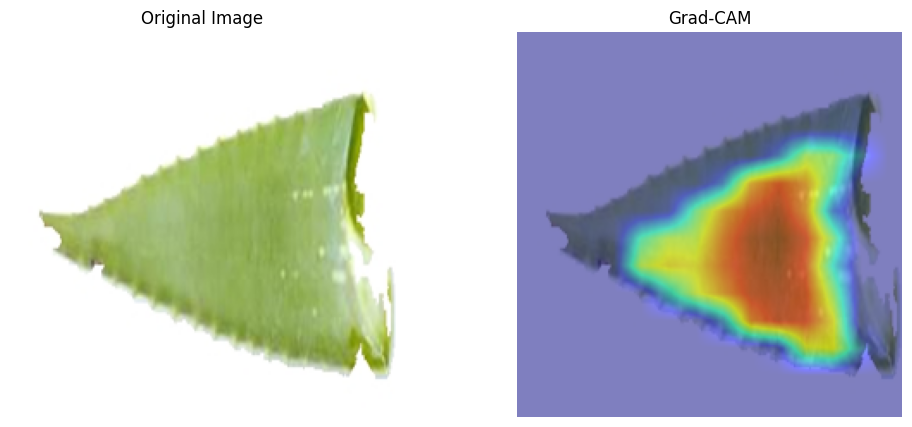


Grad-CAM saved as: gradcam_result.png


In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

Saving 11_Moringa oleifera (253).jpg to 11_Moringa oleifera (253) (1).jpg
Uploaded: 11_Moringa oleifera (253) (1).jpg

Predicted Class : Moringa_oleifera
Confidence      : 90.29 %


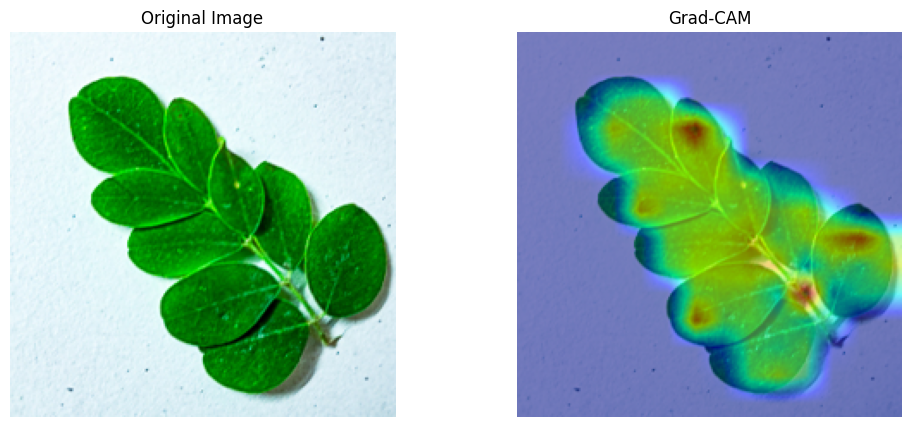


Grad-CAM saved as: gradcam_result.png


In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

Saving 11_Moringa oleifera (531).jpg to 11_Moringa oleifera (531) (1).jpg
Uploaded: 11_Moringa oleifera (531) (1).jpg

Predicted Class : Moringa_oleifera
Confidence      : 91.37 %


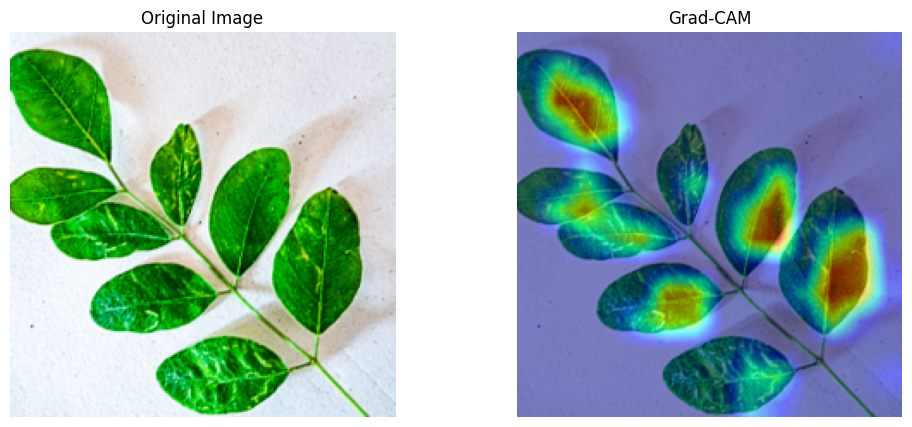


Grad-CAM saved as: gradcam_result.png


In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


ModuleNotFoundError: No module named 'pytorch_grad_cam'

In [ ]:
from google.colab import files
from grad_cam import *
from grad_cam.utils.image import show_cam_on_image
from grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

ModuleNotFoundError: No module named 'pytorch_grad_cam'

In [ ]:
# ============================================================
# GRAD-CAM FOR MANUALLY UPLOADED IMAGE
# ============================================================

from google.colab import files
from grad_cam import GradCAM
from grad_cam.utils.image import show_cam_on_image
from grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

model = VECTVMixer(NUM_CLASSES).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_vectvmixer.pth",
        map_location=device
    )
)

model.eval()

# ------------------------------------------------------------
# WRAPPER FOR GRADCAM
# ------------------------------------------------------------

class GradCAMWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):

        logits, _ = self.model(x)

        return logits

cam_model = GradCAMWrapper(model)

# ------------------------------------------------------------
# UPLOAD IMAGE FROM LAPTOP
# ------------------------------------------------------------

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded:", image_path)

# ------------------------------------------------------------
# READ IMAGE
# ------------------------------------------------------------

rgb_img = Image.open(image_path).convert("RGB")

rgb_img = rgb_img.resize((224,224))

rgb_np = np.array(rgb_img).astype(np.float32) / 255.0

# ------------------------------------------------------------
# PREPROCESS
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

input_tensor = transform(rgb_img).unsqueeze(0).to(device)

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

with torch.no_grad():

    outputs = cam_model(input_tensor)

    pred_class = outputs.argmax(dim=1).item()

    confidence = torch.softmax(outputs, dim=1)[0][pred_class].item()

print("\nPredicted Class :", CLASS_NAMES[pred_class])
print("Confidence      :", round(confidence*100,2), "%")

# ------------------------------------------------------------
# GRADCAM
# ------------------------------------------------------------

target_layer = cam_model.model.down2[0]

cam = GradCAM(
    model=cam_model,
    target_layers=[target_layer]
)

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_np,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# ------------------------------------------------------------
# SAVE RESULT
# ------------------------------------------------------------

save_path = "gradcam_result.png"

plt.imsave(
    save_path,
    visualization
)

print("\nGrad-CAM saved as:", save_path)

ModuleNotFoundError: No module named 'pytorch_grad_cam'